In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

run_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(run_device)


cpu


Dataset

In [4]:
convert_tensor = transforms.ToTensor()

mnist_train = torchvision.datasets.MNIST(root= './mnist_data', train = True, transform = convert_tensor, download = True)

mnist_test = torchvision.datasets.MNIST(root= './mnist_data', train = False, transform = convert_tensor, download = True)

train_batches = torch.utils.data.DataLoader( mnist_train, batch_size = 64, shuffle = True)

test_batches = torch.utils.data.DataLoader( mnist_test, batch_size = 64 , shuffle = False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.48MB/s]


Model

In [5]:
class DigitAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.compress = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 2)
        )

        self.expand = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, image):

        flat_image = image.view(image.size(0), -1)
        encoded_features = self.compress(flat_image)
        decoded_features = self.expand(encoded_features)
        decoded_features = decoded_features.view(image.size(0), 1, 28, 28)

        return decoded_features, encoded_features

network = DigitAutoencoder().to(run_device)
print(network)

DigitAutoencoder(
  (compress): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
  (expand): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


Loss Function & Optimiser

In [6]:
loss_function = nn.MSELoss()

optimiser = optim.Adam(
    network.parameters(),
    lr=0.001
)

Training Loop

In [7]:
num_epochs = 12
training_loss = []

for epoch in range(num_epochs):
  running_loss = 0

  for digit_images, _ in train_batches:
    digit_images = digit_images.to(run_device)
    decoded_images, encoded_values = network(digit_images)
    loss = loss_function(decoded_images, digit_images)

    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    running_loss += loss.item()

  average_loss = running_loss / len(train_batches)
  training_loss.append(average_loss)

  print(f"Epoch {epoch+1}/{num_epochs} | Loss: {average_loss:.6f}")

Epoch 1/12 | Loss: 0.058256
Epoch 2/12 | Loss: 0.047199
Epoch 3/12 | Loss: 0.044437
Epoch 4/12 | Loss: 0.042885
Epoch 5/12 | Loss: 0.041831
Epoch 6/12 | Loss: 0.041143
Epoch 7/12 | Loss: 0.040501
Epoch 8/12 | Loss: 0.039978
Epoch 9/12 | Loss: 0.039581
Epoch 10/12 | Loss: 0.039197
Epoch 11/12 | Loss: 0.038778
Epoch 12/12 | Loss: 0.038605


Plotting the loss curve

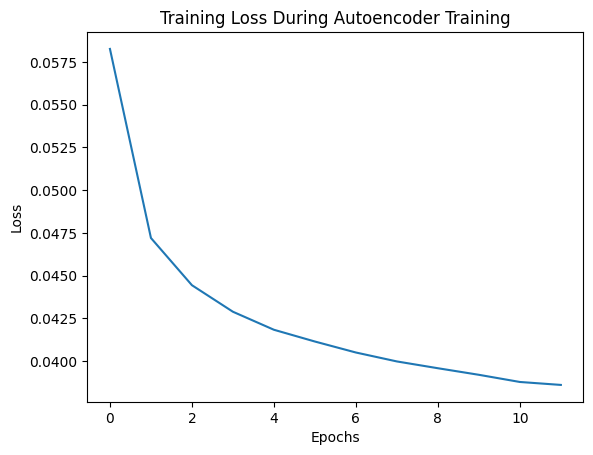

In [8]:
plt.plot(training_loss)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss During Autoencoder Training")

plt.show()

Showing Original & Reconstructed Images

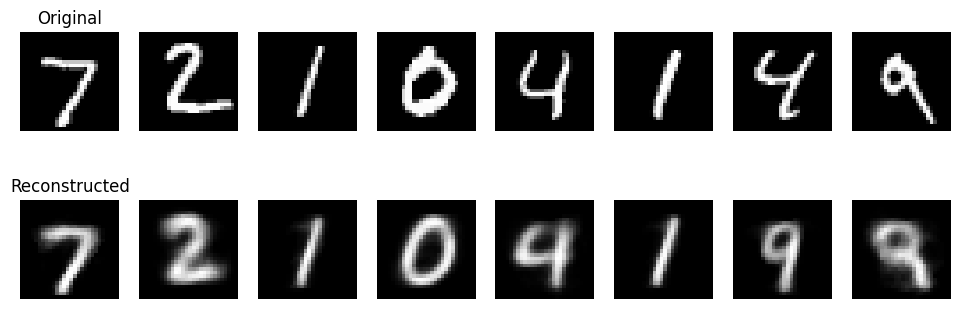

In [9]:
sample_images ,_ = next(iter(test_batches))
sample_images = sample_images.to(run_device)

with torch.no_grad():
  reconstructed_images, _ = network(sample_images)

sample_images = sample_images.cpu()
reconstructed_images = reconstructed_images.cpu()

fig, axes = plt.subplots(2, 8, figsize = (12, 4))

for i in range(8):
  axes[0, i].imshow(sample_images[i].squeeze(), cmap = "gray")
  axes[0, i].axis("off")

  axes[1, i].imshow(reconstructed_images[i].squeeze(), cmap = "gray")
  axes[1, i].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")


plt.show()

Extracting Latent Features

In [10]:
all_features = []
all_labels = []

with torch.no_grad():
  for digit_images, labels in test_batches:
    digit_images = digit_images.to(run_device)
    _, encoded_values = network(digit_images)

    all_features.append(encoded_values.cpu())
    all_labels.append(labels)

features = torch.cat(all_features)
labels = torch.cat(all_labels)


Plotting Latent Space

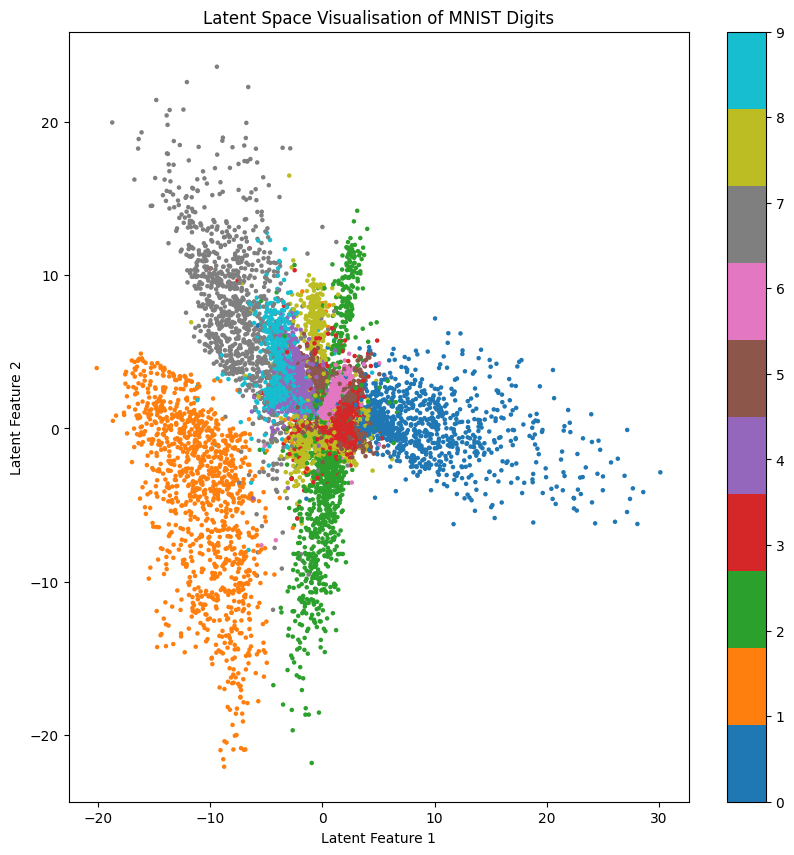

In [11]:
plt.figure(figsize = (10, 10))

scatter = plt.scatter(
    features[:, 0],
    features[:, 1],
    c = labels,
    cmap = "tab10",
    s = 5
)

plt.colorbar(scatter)

plt.xlabel("Latent Feature 1")
plt.ylabel("Latent Feature 2")

plt.title("Latent Space Visualisation of MNIST Digits")
plt.show()

Computing Test Loss

In [12]:
test_loss = 0

with torch.no_grad():
    for digit_images, _ in test_batches:
        digit_images = digit_images.to(run_device)
        decoded_images, _ = network(digit_images)
        loss = loss_function(decoded_images, digit_images)
        test_loss += loss.item()

average_test_loss = test_loss / len(test_batches)
print("Test Loss:", average_test_loss)

Test Loss: 0.03862158165188732
